<a href="https://colab.research.google.com/github/SumanthShet17/MultimodalLungCancerProgressionForecasting/blob/main/MLDL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_path = '/content/archive (17).zip'
extracted_path = '/content/extracted_data'


os.makedirs(extracted_path, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

print(f"File unzipped to: {extracted_path}")


extracted_files = os.listdir(extracted_path)
print("Extracted files:")
for file_name in extracted_files:
    print(file_name)

File unzipped to: /content/extracted_data
Extracted files:
Data


In [ ]:
import os, shutil

train_dir = "/content/extracted_data/Data/train"


rename_pairs = {
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib": "adenocarcinoma",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa": "large.cell.carcinoma",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa": "squamous.cell.carcinoma"
}

# 2. merge all images into correct folders
for old, new in rename_pairs.items():
    old_path = os.path.join(train_dir, old)
    new_path = os.path.join(train_dir, new)
    if os.path.exists(old_path):
        os.makedirs(new_path, exist_ok=True)
        moved = 0
        for f in os.listdir(old_path):
            src = os.path.join(old_path, f)
            dst = os.path.join(new_path, f)
            if os.path.isfile(src):
                shutil.move(src, dst)
                moved += 1
        shutil.rmtree(old_path)
        print(f" Moved {moved} images from {old} → {new} and deleted {old_path}")

# 3. verify result
print("\nFinal folders after cleanup:")
for c in sorted(os.listdir(train_dir)):
    p = os.path.join(train_dir, c)
    if os.path.isdir(p):
        print(f"{c:<35} : {len(os.listdir(p))} files")



Final folders after cleanup:
adenocarcinoma                      : 195 files
large.cell.carcinoma                : 115 files
normal                              : 148 files
squamous.cell.carcinoma             : 155 files


In [ ]:
!pip install -q timm torch torchvision seaborn scikit-learn tqdm

In [ ]:
import os, torch, timm, numpy as np
import torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)

 Using device: cuda


In [ ]:
train_dir = "/content/extracted_data/Data/train"
test_dir  = "/content/extracted_data/Data/test"

In [ ]:
IMG_SIZE  = 456
BATCH_SIZE = 8


In [ ]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [ ]:
progression_map = {
    "normal": 0.0,
    "adenocarcinoma": 0.5,
    "squamous.cell.carcinoma": 0.75,
    "large.cell.carcinoma": 1.0
}
class MultitaskDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.ds = datasets.ImageFolder(root, transform=transform)
        self.transform = transform
        self.class_to_idx = self.ds.class_to_idx
        self.idx_to_class = {v:k for k,v in self.class_to_idx.items()}
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        path, label = self.ds.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        class_name = self.idx_to_class[label]
        prog_score = torch.tensor(progression_map[class_name], dtype=torch.float32)
        return img, label, prog_score

train_ds = MultitaskDataset(train_dir, transform_train)
test_ds  = MultitaskDataset(test_dir,  transform_test)
classes = train_ds.ds.classes
print("Classes:", classes)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [ ]:
class MultitaskEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = timm.create_model("tf_efficientnet_b2_ns", pretrained=True, num_classes=0)
        in_feats = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.regressor = nn.Sequential(
            nn.Linear(in_feats, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        feats = self.backbone(x)
        cls_logits = self.classifier(feats)
        prog_score = self.regressor(feats)
        return cls_logits, prog_score

model = MultitaskEfficientNet(num_classes=len(classes)).to(device)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b2_ns to current tf_efficientnet_b2.ns_jft_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

In [ ]:
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)
lambda_reg = 0.4  # weight for regression part


In [ ]:
EPOCHS = 15
best_acc, best_r2 = 0.0, -1e9
train_losses, test_losses, train_accs, test_accs, val_r2s = [], [], [], [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels, scores in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        imgs, labels, scores = imgs.to(device), labels.to(device), scores.to(device).unsqueeze(1)
        optimizer.zero_grad()
        cls_logits, prog_pred = model(imgs)
        loss_cls = ce_loss(cls_logits, labels)
        loss_reg = mse_loss(prog_pred, scores)
        loss = loss_cls + lambda_reg * loss_reg
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (cls_logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    scheduler.step()

    train_loss = total_loss / len(train_dl)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels, scores in tqdm(test_dl, desc=f"Epoch {epoch}/{EPOCHS} [Test]"):
            imgs, labels, scores = imgs.to(device), labels.to(device), scores.to(device).unsqueeze(1)
            cls_logits, prog_pred = model(imgs)
            loss_cls = ce_loss(cls_logits, labels)
            loss_reg = mse_loss(prog_pred, scores)
            loss = loss_cls + lambda_reg * loss_reg
            test_loss += loss.item()
            correct += (cls_logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
            y_true.extend(scores.cpu().numpy().flatten())
            y_pred.extend(prog_pred.cpu().numpy().flatten())

    test_loss /= len(test_dl)
    test_acc = correct / total
    r2 = r2_score(y_true, y_pred)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    val_r2s.append(r2)

    print(f"\n📊 Epoch {epoch:02d} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Acc : {train_acc*100:.2f}% | Test Acc : {test_acc*100:.2f}% | R²: {r2:.4f}")

    if test_acc > best_acc:
        best_acc, best_r2 = test_acc, r2
        torch.save(model.state_dict(), "best_multitask_effnetb2.pth")

print(f"\n🏆 Best Test Accuracy: {best_acc*100:.2f}%")
print(f"🏆 Best R²: {best_r2:.4f}")

Epoch 1/15 [Test]: 100%|██████████| 40/40 [00:04<00:00,  8.18it/s]



📊 Epoch 01 Summary:
Train Loss: 0.9875 | Test Loss: 0.9204
Train Acc : 54.49% | Test Acc : 56.83% | R²: 0.6488


Epoch 2/15 [Test]: 100%|██████████| 40/40 [00:05<00:00,  6.88it/s]



📊 Epoch 02 Summary:
Train Loss: 0.6492 | Test Loss: 0.6516
Train Acc : 74.55% | Test Acc : 70.79% | R²: 0.7679


Epoch 3/15 [Test]: 100%|██████████| 40/40 [00:04<00:00,  8.19it/s]


...


📊 Epoch 13 Summary:
Train Loss: 0.0342 | Test Loss: 0.2602
Train Acc : 99.35% | Test Acc : 92.38% | R²: 0.8939


Epoch 14/15 [Test]: 100%|██████████| 40/40 [00:04<00:00,  9.30it/s]



📊 Epoch 14 Summary:
Train Loss: 0.0190 | Test Loss: 0.2535
Train Acc : 99.51% | Test Acc : 93.02% | R²: 0.9013


Epoch 15/15 [Test]: 100%|██████████| 40/40 [00:04<00:00,  9.72it/s]


📊 Epoch 15 Summary:
Train Loss: 0.0175 | Test Loss: 0.2408
Train Acc : 99.67% | Test Acc : 92.38% | R²: 0.8991

🏆 Best Test Accuracy: 94.29%
🏆 Best R²: 0.9170


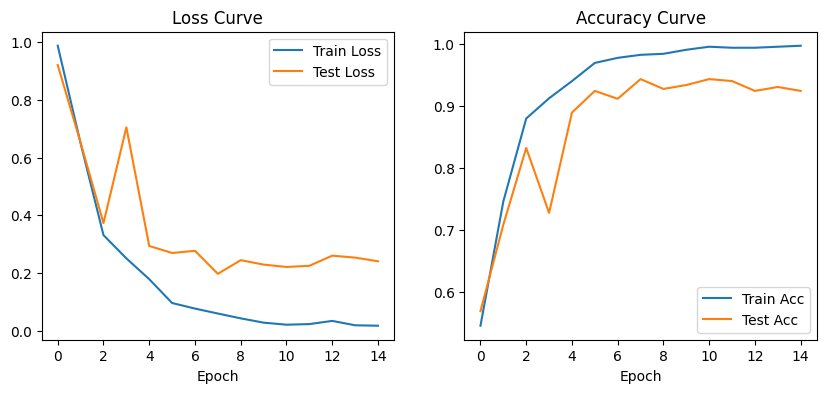

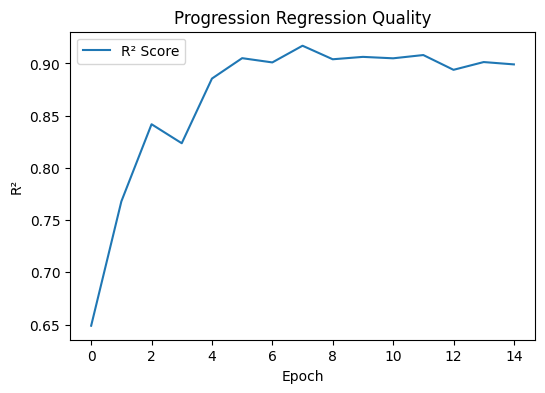

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss"); plt.plot(test_losses, label="Test Loss")
plt.legend(); plt.xlabel("Epoch"); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc"); plt.plot(test_accs, label="Test Acc")
plt.legend(); plt.xlabel("Epoch"); plt.title("Accuracy Curve")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_r2s, label="R² Score")
plt.xlabel("Epoch"); plt.ylabel("R²")
plt.title("Progression Regression Quality")
plt.legend(); plt.show()

In [ ]:
model.load_state_dict(torch.load("best_multitask_effnetb2.pth"))
model.eval()

def predict_multitask(img_path):
    img = Image.open(img_path).convert("RGB")
    t = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    x = t(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cls_logits, prog_pred = model(x)
        probs = F.softmax(cls_logits, dim=1).cpu().numpy()[0]
        prog_score = prog_pred.item()

    cls_pred = classes[np.argmax(probs)]
    print("\n Cancer Type Probabilities:")
    for c,p in zip(classes, probs):
        print(f"{c:<30}: {p*100:.2f}%")
    print(f"\n Predicted Type: {cls_pred}")
    print(f" Progression Score: {prog_score:.2f}")


    if prog_score < 0.3:
        stage = "Healthy"
    elif prog_score < 0.6:
        stage = "Early Stage"
    else:
        stage = "Advanced Stage"
    print(f" Stage Interpretation: {stage}")




 Selected image:
/content/extracted_data/Data/test/squamous.cell.carcinoma/000127 (2).png



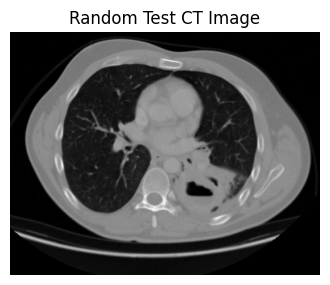

 Cancer Type Probabilities:
adenocarcinoma                : 0.35%
large.cell.carcinoma          : 0.01%
normal                        : 0.03%
squamous.cell.carcinoma       : 99.61%

 Predicted Type: squamous.cell.carcinoma
 Progression Score: 0.72
Stage Interpretation: Advanced Stage


In [ ]:
import random, glob
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F



def test_single_random_image():

    exts = ('*.png', '*.jpg', '*.jpeg')
    image_files = []
    for ext in exts:
        image_files.extend(glob.glob(f"/content/extracted_data/Data/test/*/{ext}"))

    if not image_files:
        print(" No test images found. Check your dataset path.")
        return


    img_path = random.choice(image_files)
    print(f"\n Selected image:\n{img_path}\n")


    model.load_state_dict(torch.load("best_multitask_effnetb2.pth", map_location=device))
    model.eval()


    img = Image.open(img_path)
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Random Test CT Image")
    plt.show()


    xform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    x = xform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        cls_logits, prog_pred = model(x)
        probs = F.softmax(cls_logits, dim=1).cpu().numpy()[0]
        prog_score = prog_pred.item()

    cls_pred = classes[int(probs.argmax())]

    print(" Cancer Type Probabilities:")
    for c, p in zip(classes, probs):
        print(f"{c:<30}: {p*100:.2f}%")

    print(f"\n Predicted Type: {cls_pred}")
    print(f" Progression Score: {prog_score:.2f}")

    if prog_score < 0.3:
        stage = "Healthy"
    elif prog_score < 0.6:
        stage = "Early Stage"
    else:
        stage = "Advanced Stage"

    print(f"Stage Interpretation: {stage}")

test_single_random_image()


 Final Accuracy: 87.16 %

 Confusion Matrix:
 [[   0  642]
 [   0 4358]]
 Final Accuracy: 87.16 %

 Confusion Matrix:
 [[   0  642]
 [   0 4358]]

 Classification Report:
               precision    recall  f1-score   support

          NO       0.00      0.00      0.00       642
         YES       0.87      1.00      0.93      4358

    accuracy                           0.87      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.76      0.87      0.81      5000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


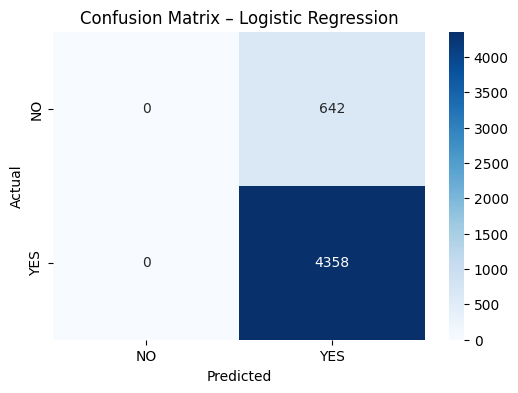

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)



df = pd.read_csv("/content/lungcanc.csv")



df.columns = df.columns.str.strip()


df['GENDER'] = df['GENDER'].map({"M": 1, "F": 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({"YES": 1, "NO": 0})

binary_cols = [
    'SMOKING','YELLOW_FINGERS','ANXIETY','PEER_PRESSURE',
    'CHRONIC DISEASE','FATIGUE','ALLERGY','WHEEZING',
    'ALCOHOL CONSUMING','COUGHING','SHORTNESS OF BREATH',
    'SWALLOWING DIFFICULTY','CHEST PAIN'
]

for col in binary_cols:
    df[col] = df[col].map({1: 0, 2: 1})


X = df.drop(columns=["LUNG_CANCER"])
y = df["LUNG_CANCER"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


clf = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=2000,
    n_jobs=-1,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


print(" Final Accuracy:", round(acc * 100, 2), "%")
print("\n Confusion Matrix:\n", cm)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['NO', 'YES'])



print(" Final Accuracy:", round(acc * 100, 2), "%")

print("\n Confusion Matrix:\n", cm)
print("\n Classification Report:\n", report)


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NO','YES'], yticklabels=['NO','YES'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()



 Found 315 test images.

===== CLINICAL MODEL (Logistic Regression) =====
Predicted Cancer Presence : YES
Cancer Probability         : 85.16%

 ===== IMAGE MODEL (EfficientNet-B2) =====

 Cancer Type Probabilities:
adenocarcinoma                : 98.81%
large.cell.carcinoma          : 0.61%
normal                        : 0.05%
squamous.cell.carcinoma       : 0.53%

 Predicted Type: adenocarcinoma
 Progression Score: 0.50
 Stage Interpretation: Early Stage

 ===== LATE FUSION (FINAL RESULTS) =====
Clinical Test Accuracy     : 87.16%
Image Model Test Accuracy  : 94.29%
Weighted Fusion Accuracy   : 90.01% (α=0.6)

 Final Fusion Prediction  : YES
Weighted Combined Probability : 0.71


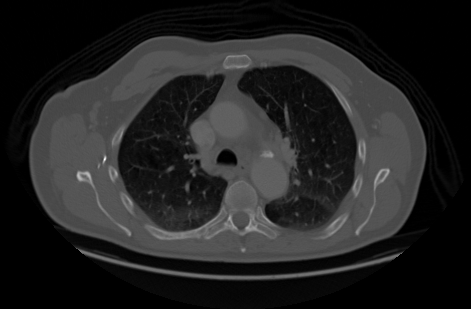

In [ ]:
import random, re, sys, glob
from io import StringIO
from PIL import Image
from IPython.display import Image as IPyImage, display
import torch.nn.functional as F
from contextlib import redirect_stdout

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




clinical_acc = acc
image_acc    = best_acc


alpha = 0.6
fusion_acc = alpha * clinical_acc + (1 - alpha) * image_acc



image_files = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_files.extend(glob.glob(f"/content/extracted_data/Data/test/*/{ext}"))

if not image_files:
    print(" No test images found in /content/extracted_data/Data/test/")
else:
    print(f" Found {len(image_files)} test images.")

idx = random.randint(0, min(len(image_files), len(X_test)) - 1)
img_path = image_files[idx]


p_clinical = clf.predict_proba([X_test[idx]])[0][1]
pred_clinical = "YES" if p_clinical > 0.5 else "NO"

print("\n===== CLINICAL MODEL (Logistic Regression) =====")
print(f"Predicted Cancer Presence : {pred_clinical}")
print(f"Cancer Probability         : {p_clinical*100:.2f}%")


print("\n ===== IMAGE MODEL (EfficientNet-B2) =====")
predict_multitask(img_path)

buffer = StringIO()
with redirect_stdout(buffer):
    predict_multitask(img_path)
output_text = buffer.getvalue()
match = re.search(r"Progression Score:\s*([0-9.]+)", output_text)
p_image = float(match.group(1)) if match else 0.0

p_fused = alpha * p_clinical + (1 - alpha) * p_image
fusion_pred = "YES" if p_fused > 0.5 else "NO"


print("\n ===== LATE FUSION (FINAL RESULTS) =====")
print(f"Clinical Test Accuracy     : {clinical_acc*100:.2f}%")
print(f"Image Model Test Accuracy  : {image_acc*100:.2f}%")
print(f"Weighted Fusion Accuracy   : {fusion_acc*100:.2f}% (α={alpha})")

print(f"\n Final Fusion Prediction  : {fusion_pred}")
print(f"Weighted Combined Probability : {p_fused:.2f}")

display(IPyImage(filename=img_path))


 Found 315 test images.

===== CLINICAL MODEL (Logistic Regression) =====
Predicted Cancer Presence : YES
Cancer Probability         : 87.08%

 ===== IMAGE MODEL (EfficientNet-B2) =====

 Cancer Type Probabilities:
adenocarcinoma                : 99.50%
large.cell.carcinoma          : 0.35%
normal                        : 0.01%
squamous.cell.carcinoma       : 0.14%

 Predicted Type: adenocarcinoma
 Progression Score: 0.50
 Stage Interpretation: Early Stage

 ===== LATE FUSION (FINAL RESULTS) =====
Clinical Test Accuracy     : 87.16%
Image Model Test Accuracy  : 94.29%
Weighted Fusion Accuracy   : 91.44% (α=0.6)

 Final Fusion Prediction  : YES
Weighted Combined Probability : 0.65


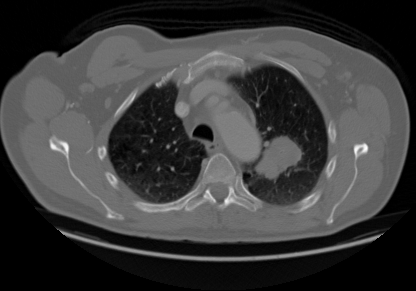

In [ ]:
import random, re, sys, glob
from io import StringIO
from PIL import Image
from IPython.display import Image as IPyImage, display
import torch.nn.functional as F
from contextlib import redirect_stdout

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




clinical_acc = acc
image_acc    = best_acc


alpha = 0.6
fusion_acc = alpha * image_acc + (1 - alpha) * clinical_acc



image_files = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_files.extend(glob.glob(f"/content/extracted_data/Data/test/*/{ext}"))

if not image_files:
    print(" No test images found in /content/extracted_data/Data/test/")
else:
    print(f" Found {len(image_files)} test images.")

idx = random.randint(0, min(len(image_files), len(X_test)) - 1)
img_path = image_files[idx]


p_clinical = clf.predict_proba([X_test[idx]])[0][1]
pred_clinical = "YES" if p_clinical > 0.5 else "NO"

print("\n===== CLINICAL MODEL (Logistic Regression) =====")
print(f"Predicted Cancer Presence : {pred_clinical}")
print(f"Cancer Probability         : {p_clinical*100:.2f}%")


print("\n ===== IMAGE MODEL (EfficientNet-B2) =====")
predict_multitask(img_path)

buffer = StringIO()
with redirect_stdout(buffer):
    predict_multitask(img_path)
output_text = buffer.getvalue()
match = re.search(r"Progression Score:\s*([0-9.]+)", output_text)
p_image = float(match.group(1)) if match else 0.0

p_fused = alpha * p_image + (1 - alpha) * p_clinical
fusion_pred = "YES" if p_fused > 0.5 else "NO"


print("\n ===== LATE FUSION (FINAL RESULTS) =====")
print(f"Clinical Test Accuracy     : {clinical_acc*100:.2f}%")
print(f"Image Model Test Accuracy  : {image_acc*100:.2f}%")
print(f"Weighted Fusion Accuracy   : {fusion_acc*100:.2f}% (α={alpha})")

print(f"\n Final Fusion Prediction  : {fusion_pred}")
print(f"Weighted Combined Probability : {p_fused:.2f}")

display(IPyImage(filename=img_path))


#INFERENCE TESTING USING THE LOADED MODEL WEIGHTS

In [ ]:
#INFERENCE
model.load_state_dict(torch.load("best_multitask_effnetb2 (2).pth"))
model.eval()

def predict_multitask(img_path):
    img = Image.open(img_path).convert("RGB")
    t = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    x = t(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cls_logits, prog_pred = model(x)
        probs = F.softmax(cls_logits, dim=1).cpu().numpy()[0]
        prog_score = prog_pred.item()

    cls_pred = classes[np.argmax(probs)]
    print("\n Cancer Type Probabilities:")
    for c,p in zip(classes, probs):
        print(f"{c:<30}: {p*100:.2f}%")
    print(f"\n Predicted Type: {cls_pred}")
    print(f" Progression Score: {prog_score:.2f}")


    if prog_score < 0.3:
        stage = "Healthy"
    elif prog_score < 0.6:
        stage = "Early Stage"
    else:
        stage = "Advanced Stage"
    print(f" Stage Interpretation: {stage}")




 Selected image:
/content/extracted_data/Data/test/adenocarcinoma/000158 (3).png



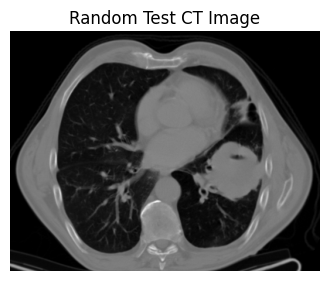

 Cancer Type Probabilities:
adenocarcinoma                : 0.06%
large.cell.carcinoma          : 99.87%
normal                        : 0.00%
squamous.cell.carcinoma       : 0.08%

 Predicted Type: large.cell.carcinoma
 Progression Score: 0.99
Stage Interpretation: Advanced Stage


In [ ]:
import random, glob
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F



def test_single_random_image():

    exts = ('*.png', '*.jpg', '*.jpeg')
    image_files = []
    for ext in exts:
        image_files.extend(glob.glob(f"/content/extracted_data/Data/test/*/{ext}"))

    if not image_files:
        print(" No test images found. Check your dataset path.")
        return


    img_path = random.choice(image_files)
    print(f"\n Selected image:\n{img_path}\n")


    model.load_state_dict(torch.load("best_multitask_effnetb2 (2).pth", map_location=device))
    model.eval()


    img = Image.open(img_path)
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Random Test CT Image")
    plt.show()


    xform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    x = xform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        cls_logits, prog_pred = model(x)
        probs = F.softmax(cls_logits, dim=1).cpu().numpy()[0]
        prog_score = prog_pred.item()

    cls_pred = classes[int(probs.argmax())]

    print(" Cancer Type Probabilities:")
    for c, p in zip(classes, probs):
        print(f"{c:<30}: {p*100:.2f}%")

    print(f"\n Predicted Type: {cls_pred}")
    print(f" Progression Score: {prog_score:.2f}")

    if prog_score < 0.3:
        stage = "Healthy"
    elif prog_score < 0.6:
        stage = "Early Stage"
    else:
        stage = "Advanced Stage"

    print(f"Stage Interpretation: {stage}")

test_single_random_image()


 Found 315 test images.

===== CLINICAL MODEL (Logistic Regression) =====
Predicted Cancer Presence : YES
Cancer Probability         : 85.16%

 ===== IMAGE MODEL (EfficientNet-B2) =====

 Cancer Type Probabilities:
adenocarcinoma                : 98.81%
large.cell.carcinoma          : 0.61%
normal                        : 0.05%
squamous.cell.carcinoma       : 0.53%

 Predicted Type: adenocarcinoma
 Progression Score: 0.50
 Stage Interpretation: Early Stage

 ===== LATE FUSION (FINAL RESULTS) =====
Clinical Test Accuracy     : 87.16%
Image Model Test Accuracy  : 94.29%
Weighted Fusion Accuracy   : 91.44% (α=0.6)

 Final Fusion Prediction  : YES
Weighted Combined Probability : 0.64


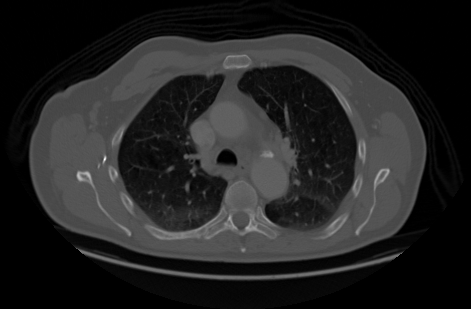

In [ ]:
import random, re, sys, glob
from io import StringIO
from PIL import Image
from IPython.display import Image as IPyImage, display
import torch.nn.functional as F
from contextlib import redirect_stdout

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




clinical_acc = acc
image_acc    = best_acc


alpha = 0.6
fusion_acc = alpha * image_acc + (1 - alpha) * clinical_acc



image_files = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_files.extend(glob.glob(f"/content/extracted_data/Data/test/*/{ext}"))

if not image_files:
    print(" No test images found in /content/extracted_data/Data/test/")
else:
    print(f" Found {len(image_files)} test images.")

idx = random.randint(0, min(len(image_files), len(X_test)) - 1)
img_path = image_files[idx]


p_clinical = clf.predict_proba([X_test[idx]])[0][1]
pred_clinical = "YES" if p_clinical > 0.5 else "NO"

print("\n===== CLINICAL MODEL (Logistic Regression) =====")
print(f"Predicted Cancer Presence : {pred_clinical}")
print(f"Cancer Probability         : {p_clinical*100:.2f}%")


print("\n ===== IMAGE MODEL (EfficientNet-B2) =====")
predict_multitask(img_path)

buffer = StringIO()
with redirect_stdout(buffer):
    predict_multitask(img_path)
output_text = buffer.getvalue()
match = re.search(r"Progression Score:\s*([0-9.]+)", output_text)
p_image = float(match.group(1)) if match else 0.0

p_fused = alpha * p_image + (1 - alpha) * p_clinical
fusion_pred = "YES" if p_fused > 0.5 else "NO"


print("\n ===== LATE FUSION (FINAL RESULTS) =====")
print(f"Clinical Test Accuracy     : {clinical_acc*100:.2f}%")
print(f"Image Model Test Accuracy  : {image_acc*100:.2f}%")
print(f"Weighted Fusion Accuracy   : {fusion_acc*100:.2f}% (α={alpha})")

print(f"\n Final Fusion Prediction  : {fusion_pred}")
print(f"Weighted Combined Probability : {p_fused:.2f}")

display(IPyImage(filename=img_path))
